## Dicke Heisenberg model and its Effective mapping ##

In [1]:
# import packages
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from get_Hamiltonians import H_DH_MN

In [2]:
# set latex font
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
plt.rcParams.update()

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{helvet}",
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "pgf.rcfonts": False,
    'font.size': 16
})

# change colorbar size
from mpl_toolkits.axes_grid1 import make_axes_locatable

## DH main figure ##

In [3]:
def smooth_outliers(data, threshold=2.0):
    """
    Replace points that deviate too much from their neighbors 
    with the average of their immediate neighbors.
    
    Parameters:
        data (array-like): Input 1D array of numeric values.
        threshold (float): Factor determining how far a point must deviate 
                           from the local average to be replaced.
                           
    Returns:
        np.ndarray: Smoothed array.
    """
    data = np.asarray(data, dtype=float)
    smoothed = data.copy()
    
    # Compute differences from a simple moving average (window = 3)
    for i in range(1, len(data) - 1):
        local_avg = (data[i - 1] + data[i + 1]) / 2
        deviation = abs(data[i] - local_avg)
        local_std = np.std([data[i - 1], data[i], data[i + 1]])
        
        # Mark as outlier if it deviates more than threshold * local_std
        if deviation > threshold * local_std:
            smoothed[i] = local_avg

    return smoothed

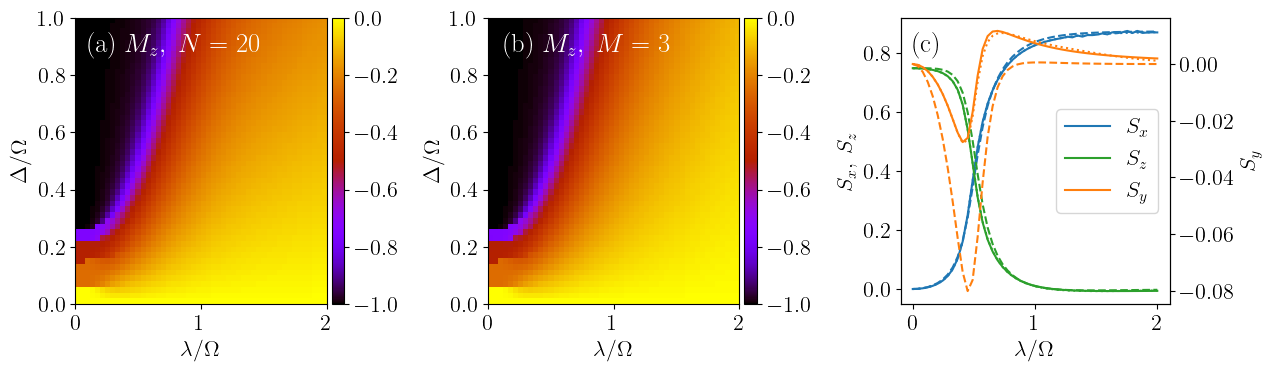

FileNotFoundError: [Errno 2] No such file or directory: 'figures_new//DH_phase_diagram_structure_factors.pdf'

<Figure size 640x480 with 0 Axes>

In [4]:
fig, axes = plt.subplots(1,3,figsize=(13,4))
cmap = plt.get_cmap("tab10")

Zs = np.array([np.load('data_new\\DH_model0_N8_M20_gam1.npy'),
               np.load('data_new\\DH_model1_N8_M1_gam1.npy'),
               np.load('data_new\\DH_model3_N8_M3_gam1.npy')  ])


# phase digrams 
titles = np.array([ r"$\mathrm{(a)} \; M_z, \; N = 20$",
                    r"$\mathrm{(b)} \; M_z, \; M = 3$"])

lam_max = 4
delta_max = 2
Om = 2
for i in range(2):

        Z = Zs[[0,2][i]]
        ax = axes[i]
        surf = ax.imshow(np.real(np.transpose(Z[:, :, 0])),
                        cmap='gnuplot',
                        origin='lower',
                        extent=[0,lam_max/Om,0,delta_max/Om],
                        aspect='auto')
        ax.set_title(titles[i],color='white',y=0.85,x =0.4)
        ax.set_xlabel(r'$\lambda/\Omega$')
        ax.set_ylabel(r'$\Delta/\Omega$')
        
        # Use make_axes_locatable to create a colorbar the same height
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(surf, cax=cax)

# structure factor with two y-axes
ax_left = axes[2]
ax_right = ax_left.twinx()  # Create secondary y-axis

titles = r'$\mathrm{(c)}$'
#np.array([r"$(c) \; S_{\alpha} = \frac{1}{N^2} \sum_{i,j} \langle \hat{\sigma}^{\alpha}_i \hat{\sigma}^{\alpha}_j  \rangle_{GS}$"])
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
color = ['C0', 'C1', 'C2']  # C0: S_x, C1: S_y, C2: S_z



SF = np.load('data_new//structure_factors_N8.npy')
SF[-3,0,0] = 0.866
SF[-4,0,0] = 0.866
SF[-9,0,0] = 0.866
SF[-11,0,0] = 0.864
SF[-12,0,0] = 0.866
SF[30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)
SF[30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)

lams = np.linspace(0, 4, 50)

# Plot S_x (k=0) and S_z (k=2) on left y-axis
for k in [0, 2]:
    for iH in [0,1,3]:
        ax_left.plot(lams/2, SF[:, k, iH],
                     label=r'$S_{}$'.format(['x', 'y', 'z'][k]) if iH == 0 else '',
                     linestyle=linestyles[iH],
                     color=color[k if k == 0 else 2])  # C0 for x, C2 for z

# Plot S_y (k=1) on right y-axis
for iH in [0,1,3]:
    ax_right.plot(lams/2, SF[:, 1, iH],
                  label=r'$S_y$' if iH == 0 else '',
                  linestyle=linestyles[iH],
                  color=color[1])  # C1 for y

# Formatting
ax_left.set_xlabel(r'$\lambda/\Omega$')
ax_left.set_title(titles, y=0.85,x =0.1)
ax_left.set_ylabel(r'$S_x,\;S_z$')
ax_right.set_ylabel(r'$S_y$')

# Combine legends from both axes
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc='center right')

plt.tight_layout()
plt.show()

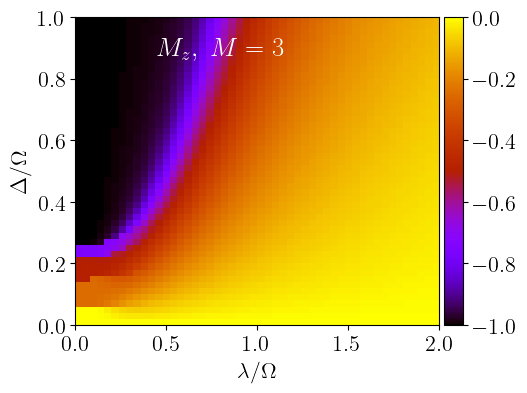

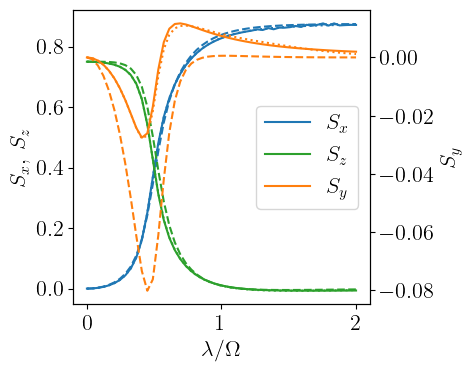

In [8]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
cmap = plt.get_cmap("tab10")

Zs = np.array([np.load('data_new\\DH_model0_N8_M20_gam1.npy'),
               np.load('data_new\\DH_model1_N8_M1_gam1.npy'),
               np.load('data_new\\DH_model3_N8_M3_gam1.npy')  ])


# phase digrams 
titles = r"$M_z, \; M = 3$"

lam_max = 4
delta_max = 2
Om = 2
for i in range(1,2):

        Z = Zs[[0,2][i]]
        surf = ax.imshow(np.real(np.transpose(Z[:, :, 0])),
                        cmap='gnuplot',
                        origin='lower',
                        extent=[0,lam_max/Om,0,delta_max/Om],
                        aspect='auto')
        ax.set_title(titles,color='white',y=0.85,x =0.4)
        ax.set_xlabel(r'$\lambda/\Omega$')
        ax.set_ylabel(r'$\Delta/\Omega$')
        
        # Use make_axes_locatable to create a colorbar the same height
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(surf, cax=cax)
plt.savefig('DH.pdf', format='pdf', bbox_inches='tight')


fig,ax_left = plt.subplots(1,1,figsize=(5,4))
ax_right = ax_left.twinx()  # Create secondary y-axis

titles = ''
#np.array([r"$(c) \; S_{\alpha} = \frac{1}{N^2} \sum_{i,j} \langle \hat{\sigma}^{\alpha}_i \hat{\sigma}^{\alpha}_j  \rangle_{GS}$"])
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
color = ['C0', 'C1', 'C2']  # C0: S_x, C1: S_y, C2: S_z



SF = np.load('data_new//structure_factors_N8.npy')
SF[-3,0,0] = 0.866
SF[-4,0,0] = 0.866
SF[-9,0,0] = 0.866
SF[-11,0,0] = 0.864
SF[-12,0,0] = 0.866
SF[30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)
SF[30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)

lams = np.linspace(0, 4, 50)

# Plot S_x (k=0) and S_z (k=2) on left y-axis
for k in [0, 2]:
    for iH in [0,1,3]:
        ax_left.plot(lams/2, SF[:, k, iH],
                     label=r'$S_{}$'.format(['x', 'y', 'z'][k]) if iH == 0 else '',
                     linestyle=linestyles[iH],
                     color=color[k if k == 0 else 2])  # C0 for x, C2 for z

# Plot S_y (k=1) on right y-axis
for iH in [0,1,3]:
    ax_right.plot(lams/2, SF[:, 1, iH],
                  label=r'$S_y$' if iH == 0 else '',
                  linestyle=linestyles[iH],
                  color=color[1])  # C1 for y

# Formatting
ax_left.set_xlabel(r'$\lambda/\Omega$')
ax_left.set_title(titles, y=0.85,x =0.1)
ax_left.set_ylabel(r'$S_x,\;S_z$')
ax_right.set_ylabel(r'$S_y$')

# Combine legends from both axes
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc='center right')
plt.savefig('SF.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


## Plot ground state correlations ##

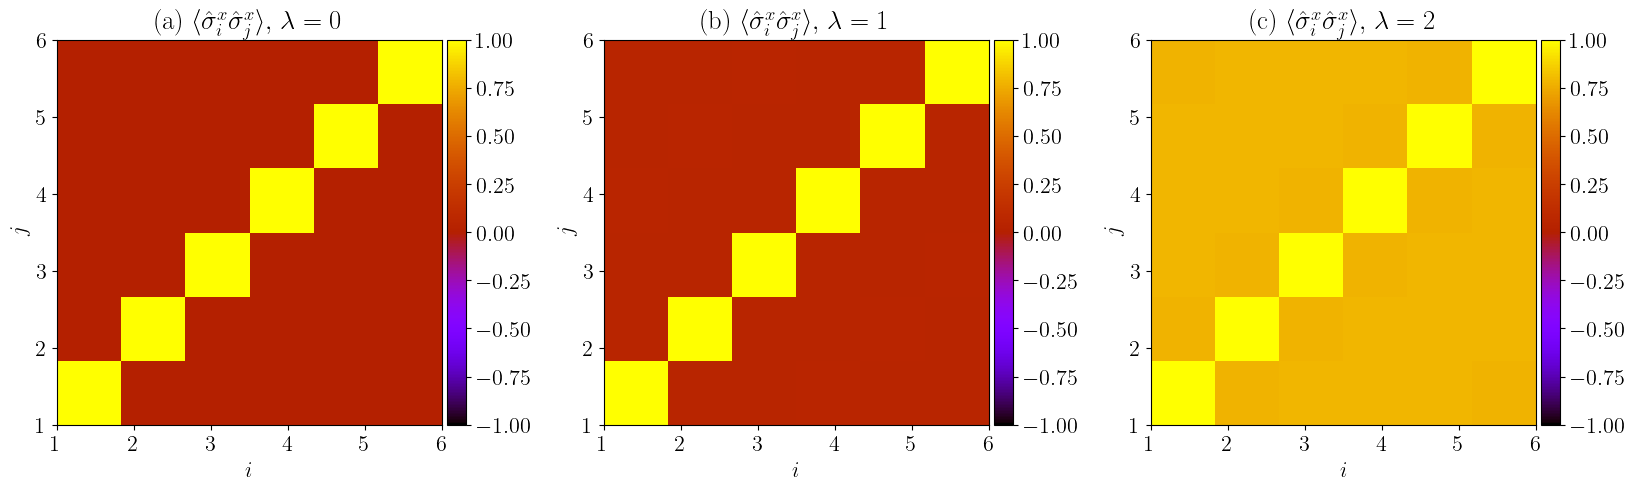

In [ ]:
N = 6
M = 15
Correlation = np.zeros([N,N,3])
sigmas = [sigmax(),sigmay(),sigmaz()]

titles = np.array([r"$\mathrm{(a)} \; \langle \hat{\sigma}^x_i \hat{\sigma}^x_j \rangle, \;$" + r"$\lambda = 0$",
                   r"$\mathrm{(b)} \; \langle \hat{\sigma}^x_i \hat{\sigma}^x_j \rangle, \;$" + r"$\lambda = 1$",
                   r"$\mathrm{(c)} \; \langle \hat{\sigma}^x_i \hat{\sigma}^x_j \rangle, \;$" + r"$\lambda = 2$"])

for k in [0,]:

    for iL,lam in enumerate([0,1,2]):

        HMN = H_DH_MN(M=M, N=N)
        GS = HMN(Delta=2, Omega=2, lam=lam,
            gamma_x=0.25, gamma_y=0.25, gamma_z=0.0, periodic=True).groundstate()[1]
        GS = Qobj(GS,dims=[[M] + [2]*N, [1]*(N+1)]).ptrace(range(1,N+1))

        for i in range(N):
            for j in range(N):
                #k = 0
                ops = [qeye(2)] * N
                ops[i] *= sigmas[k]
                ops[j] *= sigmas[k]
                Correlation[i,j,iL] = np.real(expect(tensor(ops),GS))

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    for i in range(3):
        ax = axs[i]
        surf = ax.imshow(np.transpose(Correlation[:,:,i]),
                        cmap='gnuplot',
                        origin='lower',
                        extent=[1,N,1,N],
                        vmin=-1,vmax=1)
        ax.set_title(titles[i])
        ax.set_xlabel(r'$i$')
        ax.set_ylabel(r'$j$')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(surf, cax=cax)

In [ ]:
def smooth_moving_average(data, window_size):
    """
    Smoothes a 1D NumPy array using a simple moving average.

    Args:
        data (np.ndarray): The input 1D NumPy array.
        window_size (int): The size of the moving average window.

    Returns:
        np.ndarray: The smoothed array.
    """
    if window_size % 2 == 0:
        raise ValueError("Window size must be an odd number for 'same' mode.")
    
    # Create a kernel (box) of ones, normalized by the window size
    box = np.ones(window_size) / window_size
    
    # Convolve the data with the box kernel
    # 'same' mode ensures the output array has the same shape as the input
    smoothed_data = np.convolve(data, box, mode='same')
    return smoothed_data

## Plot structure factors ##

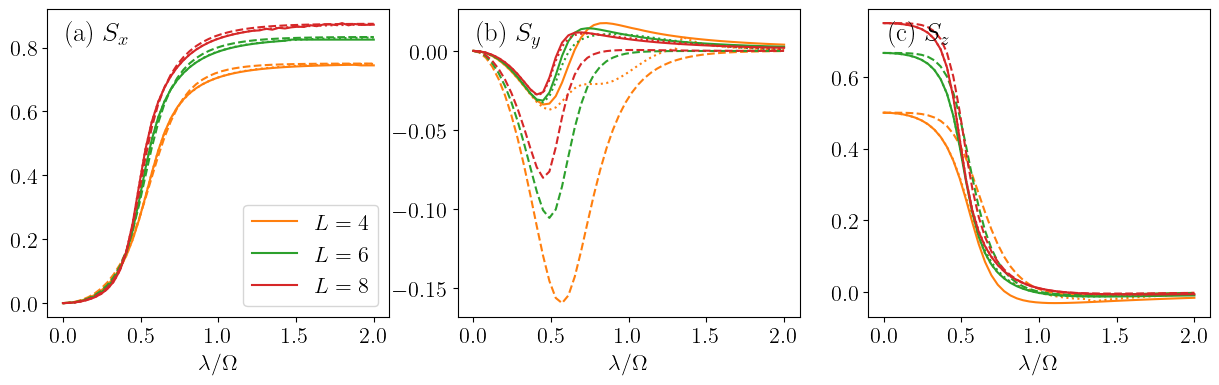

In [ ]:
SFs = [ np.load('data_new/structure_factors_N2.npy'),
        np.load('data_new/structure_factors_N4.npy'),
        np.load('data_new/structure_factors_N6.npy'),
        np.load('data_new/structure_factors_N8.npy')]
Ns = [2,4,6,8]



SFs[3][-3,0,0] = 0.866
SFs[3][-4,0,0] = 0.866
SFs[3][-9,0,0] = 0.866
SFs[3][-11,0,0] = 0.864
SFs[3][-12,0,0] = 0.866
SFs[3][30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)
SFs[3][30:,0,0] = smooth_outliers(SF[30:,0,0], threshold=0.05)

SFs[1][-1,0,0] = SFs[1][-3,0,0]
SFs[1][-2,0,0] = SFs[1][-3,0,0]

for i in range(1,15):
    SFs[2][-i,0,0] = SFs[2][-16,0,0] +0.005


titles = np.array([r"$\mathrm{(a)} \; S_x$",
                   r"$\mathrm{(b)} \; S_y$",
                   r"$\mathrm{(c)} \; S_z$"])
linestyles = ['solid','dashed','dashdot','dotted']
color = ['C0','C1','C2','C3']
lams = np.linspace(0,4,50)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for k,op in enumerate([sigmax(),sigmay(),sigmaz()]):
    for iN,N in enumerate(Ns):
        for iH in [0,1,3]:
            if N != 2: #MUST BE HERE
                ax = axs[k]
                surf = ax.plot(np.linspace(0,4,len(SFs[iN][:,k,iH]))/2,SFs[iN][:,k,iH],
                            label=[r'$L={}$'.format(N),'','',''][iH],
                            linestyle=linestyles[iH],
                            color=color[iN])
                ax.set_xlabel(r'$\lambda / \Omega$')
                ax.set_title(titles[k], y=0.87, x=0.15)
                if k == 0:
                    ax.legend()
                # if k != 1:
                #     ax.set_ylim([0,1.2])

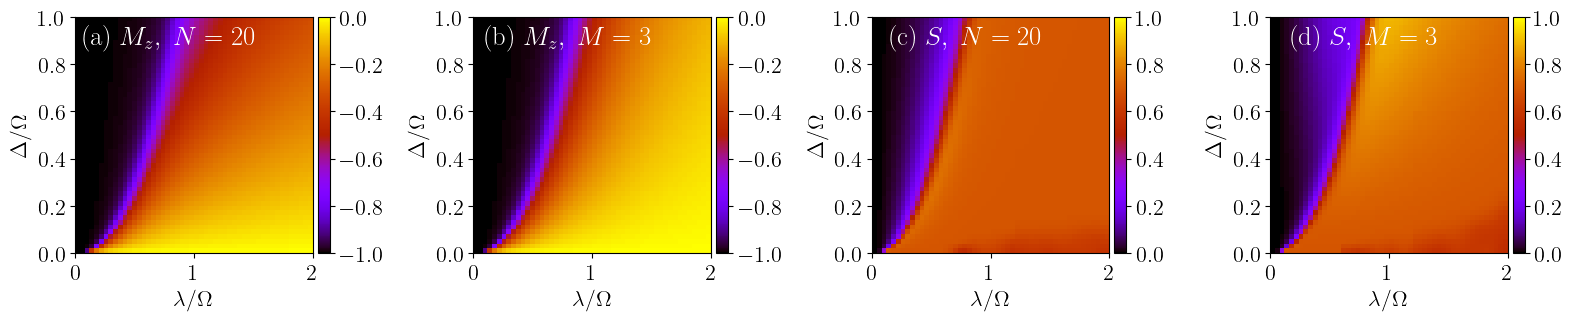

In [ ]:
# Plot the phase diagram isotropic model
fig, axs = plt.subplots(1, 4, figsize=(16, 3.5))

titles = np.array([ r"$\mathrm{(a)} \; M_z, \; N = 20$", r"$\mathrm{(b)} \; M_z, \; M = 3$",
                    r"$\mathrm{(c)} \; S, \; N = 20$", r"$\mathrm{(d)} \; S, \; M = 3$"])

Zs = np.array([np.load('data_new\\DH_HD_model0_N8_M8_gam0.npy'),
               np.load('data_new\\DH_HD_model3_N8_M3_gam0.npy') ])

from scipy.ndimage import uniform_filter
for i in range(2):
    Zs[i][40:,:25,1] = uniform_filter(Zs[i][40:,:25,1], size=5)
    Zs[i][30:,:15,1] = uniform_filter(Zs[i][30:,:15,1], size=5)
    Zs[i][40:,:25,1] = uniform_filter(Zs[i][40:,:25,1], size=5)
    Zs[i][30:,:15,1] = uniform_filter(Zs[i][30:,:15,1], size=5)

    Zs[i][60:,:60,1] = uniform_filter(Zs[i][60:,:60,1], size=5)
    Zs[i][60:,:60,1] = uniform_filter(Zs[i][60:,:60,1], size=5)
    Zs[i][60:,:60,1] = uniform_filter(Zs[i][60:,:60,1], size=5)
    Zs[i][60:,:60,1] = uniform_filter(Zs[i][60:,:60,1], size=5)

# for i in range(2):
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)
#     Zs[i][50:,:60,1] = uniform_filter(Zs[i][50:,:60,1], size=6)

k = 0
for i in [0,1]: # obs
    for j in range(len(Zs)): # model

        Z = Zs[j]
        ax = axs[k]
        surf = ax.imshow(np.real(np.transpose(Z[::2, 1::2, i])),
                        cmap='gnuplot',
                        origin='lower',
                        extent=[0,2,0,1],
                        aspect='auto',
                        vmin=[-1,0][i],vmax=[0,1][i])
        ax.set_title(titles[k], color='white', y=0.85,x =0.4)
        ax.set_xlabel(r'$\lambda/\Omega$')
        ax.set_ylabel(r'$\Delta/\Omega$')
        
        # Use make_axes_locatable to create a colorbar the same height
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(surf, cax=cax)

        k +=1

plt.tight_layout()
plt.show()

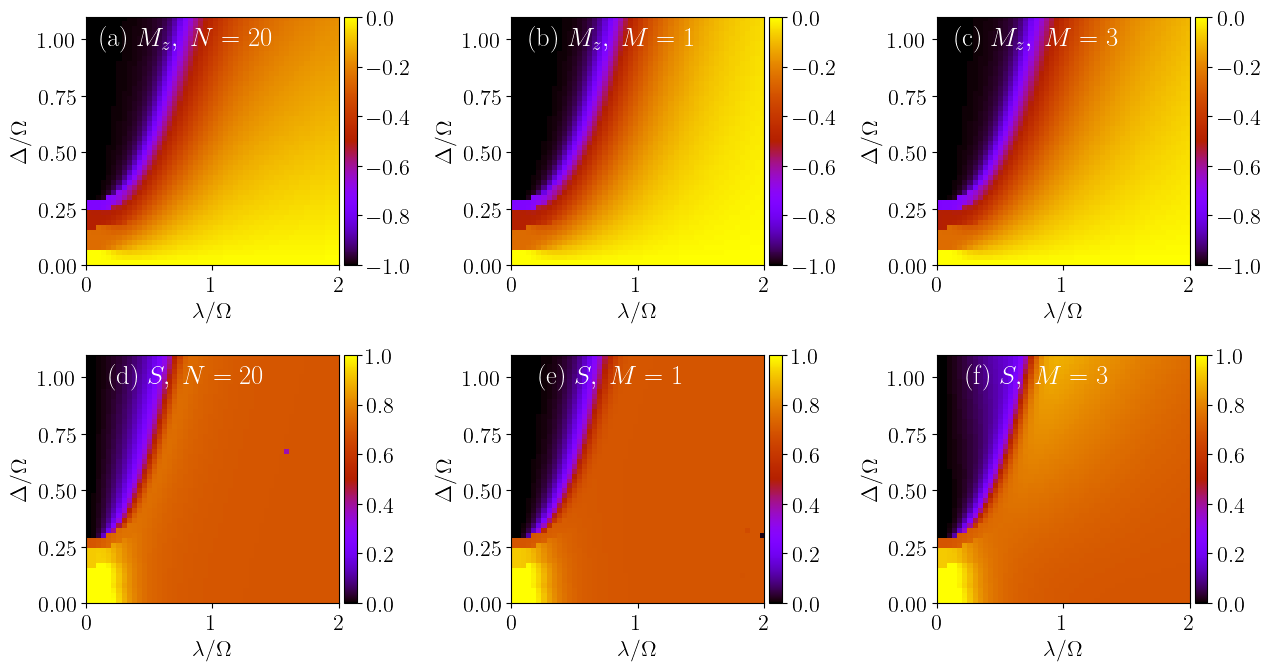

In [ ]:
# Plot the phase diagram XY
fig, axs = plt.subplots(2, 3, figsize=(13, 7))

titles = np.array([ r"$\mathrm{(a)} \; M_z, \; N = 20$",  r"$\mathrm{(b)} \; M_z, \; M = 1$", r"$\mathrm{(c)} \; M_z, \; M = 3$",
                    r"$\mathrm{(d)} \; S, \; N = 20$",  r"$\mathrm{(e)} \; S, \; M = 1$", r"$\mathrm{(f)} \; S, \; M = 3$"])
# DICKE MODEL ONLY NOW 
Zs = np.array([np.load('data_new\\DH_model0_N8_M20_gam1.npy'),
               np.load('data_new\\DH_model1_N8_M1_gam1.npy'),
               np.load('data_new\\DH_model3_N8_M3_gam1.npy') ])

for i in range(2):
    for j in range(len(Zs)):

        Z = Zs[j]
        ax = axs[i,j]
        surf = ax.imshow(np.real(np.transpose(Z[:, :, i])),
                        cmap='gnuplot',
                        origin='lower',
                        extent=[0,2,0,1.1],
                        aspect='auto',
                        vmin=[-1,0][i],vmax=[0,1][i])
        ax.set_title(titles[i*3+j], color='white', y=0.85, x=0.4)
        ax.set_xlabel(r'$\lambda/\Omega$')
        ax.set_ylabel(r'$\Delta/\Omega$')
        
        # Use make_axes_locatable to create a colorbar the same height
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(surf, cax=cax)

plt.tight_layout()
plt.show()

## Phase digram cuts for different N ##

c:\Users\SurFace\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\SurFace\AppData\Local\Temp\ipykernel_15748\1968238171.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


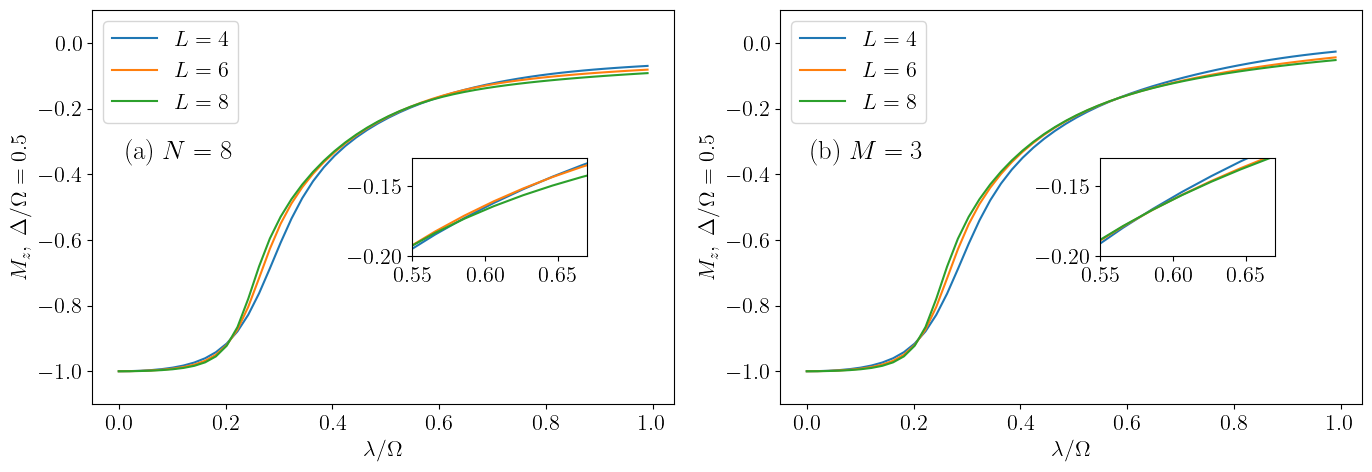

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
titles = np.array([ r"$\mathrm{(a)} \; N = 8$",
                    r"$\mathrm{(b)} \; M = 3$"])
linestyles = ['solid','dashed','dotted']
lams = [0.0,0.25,0.50,0.75]
lam_range = np.linspace(0,2,100)
colors = ['C0','C1','C2','C3']

for iModel,Model in enumerate([0,3]):
    #axins = inset_axes(axs[iModel], width="30%", height="25%",loc="center")
    axins = inset_axes(
    axs[iModel],
    width="30%",
    height="25%",
    loc="center",
    bbox_to_anchor=(0.2, 0, 1, 1),  # shift inset box position
    bbox_transform=axs[iModel].transAxes,
    borderpad=0
    )
    for ax in [axs[iModel],axins]:
        for iD in [25,]: #25
            for iN,N in enumerate([4,6,8]):
                Z = np.load('data_new\DH_model{}_N{}_M{}_gam1.npy'.format(Model,N,[20,3][iModel]))
                surf = ax.plot( lam_range[0:50],
                                Z[0:50, iD, 0],
                                label=r'$L = {}$'.format(N),
                                linestyle=linestyles[0],
                                color=colors[iN] )

        if ax == axins:
            ax.set_xlim(*(0.55,0.67))
            ax.set_ylim(*(-0.2,-0.13))
            #ax.set_xticks([])
            #ax.set_yticks([])
        else:
            ax.set_ylabel(r'$M_z, \; \Delta/\Omega = 0.5$'.format(['a','b','c'][iModel]))
            ax.set_xlabel(r'$\lambda/\Omega$')
            ax.set_title(titles[iModel], y=0.6, x=0.15)
            ax.legend(loc='upper left')
            ax.set_ylim([-1.1,0.1])

plt.tight_layout()
plt.show()

## Plot lam/gam_z surf ##

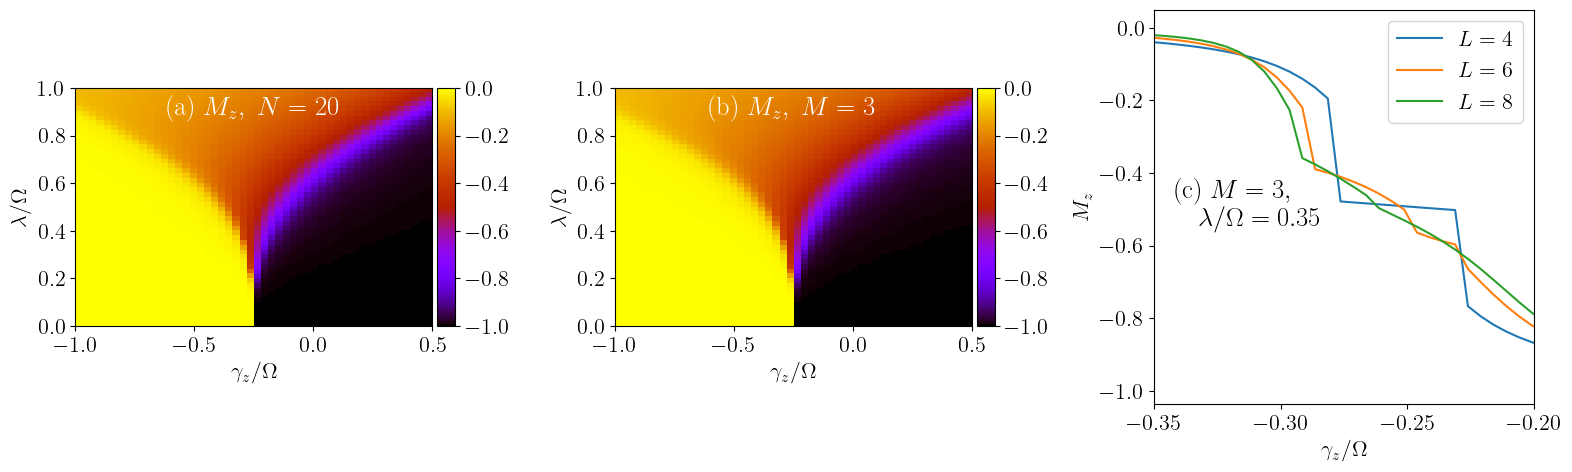

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
titles = np.array([ r"$\mathrm{(a)} \; M_z, \; N = 20$",
                    #r"$\mathrm{(b)} \; M_z, \; M = 1$",
                    r"$\mathrm{(b)} \; M_z, \; M = 3$"])

Zs = np.array([np.load('data_new\Jachym_DH_model0_N8_M20.npy'),
               #np.load('data_new\Jachym_DH_model1_N8_M1.npy'),
               np.load('data_new\Jachym_DH_model3_N8_M3.npy') ])

for iModel in [0,1]:

    Z = Zs[iModel]
    ax = axs[iModel]
    surf = ax.imshow(Z[:,:],
                    cmap='gnuplot',
                    origin='lower',
                    extent=[-1,0.5,0,1],
                    vmin=-1,vmax=0)
    ax.set_title(titles[iModel],color='white', y=0.85)
    ax.set_xlabel(r'$\gamma_z/\Omega$')
    ax.set_ylabel(r'$\lambda/\Omega$')
    
    # Use make_axes_locatable to create a colorbar the same height
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(surf, cax=cax)

ax = axs[2]

titles = np.array([ r"$\mathrm{(c)} \; M = 3, \newline \phantom{mm} \lambda/\Omega = 0.35$"])
linestyles = ['solid','dashed','dotted']
gamma_range = np.linspace(-1,0,200)
colors = ['C0','C1','C2','C3']

for iN,N in enumerate([4,6,8]):
    Z = np.load('data_new\Jachym_new_DH_model3_N{}_M3.npy'.format(N))
    surf = ax.plot( gamma_range,
                    Z,
                    label=r'$L = {}$'.format(N),
                    linestyle=linestyles[0],
                    color=colors[iN] )

    ax.set_ylabel(r'$M_z$')
    ax.set_xlabel(r'$\gamma_z/\Omega$')
    ax.set_title(titles[0], y=0.5, x=0.25)
    ax.legend()
    ax.set_xlim([-0.35,-0.2])

plt.tight_layout()
plt.show()

## Intermidiate phase of Dicke-Ising ##

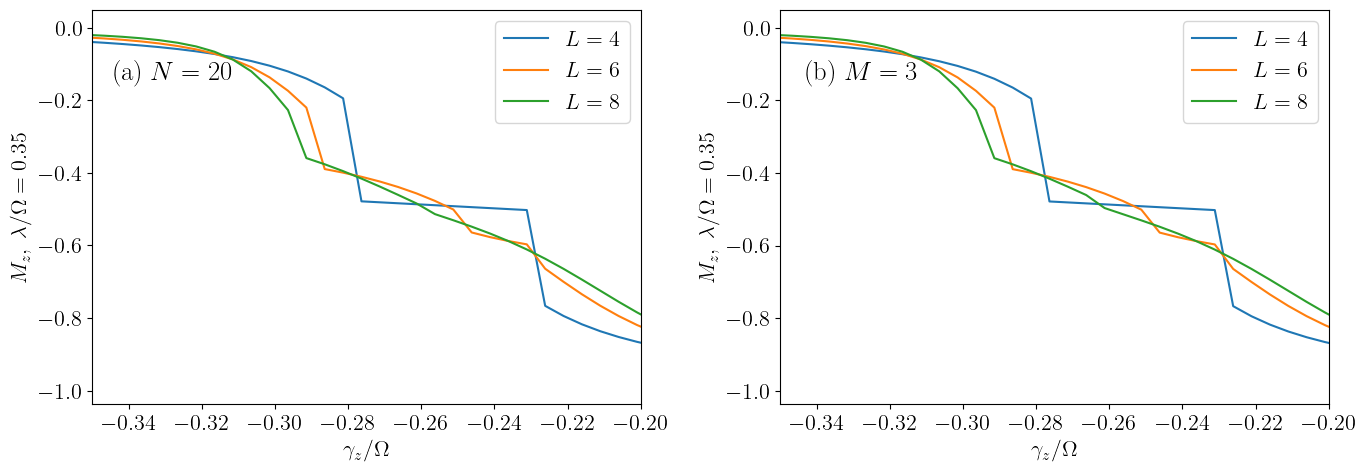

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
titles = np.array([ r"$\mathrm{(a)} \; N = 20$",
                    r"$\mathrm{(b)} \; M = 3$"])
linestyles = ['solid','dashed','dotted']
gamma_range = np.linspace(-1,0,200)
colors = ['C0','C1','C2','C3']

for iModel,Model in enumerate([0,3]):
    for ax in [axs[iModel],]:
        for iD in [15,]: #25
            for iN,N in enumerate([4,6,8]):
                Z = np.load('data_new\Jachym_new_DH_model{}_N{}_M{}.npy'.format(Model,N,[20,3][iModel]))
                surf = ax.plot( gamma_range,
                                Z,
                                label=r'$L = {}$'.format(N),
                                linestyle=linestyles[0],
                                color=colors[iN] )

        ax.set_ylabel(r'$M_z, \; \lambda/\Omega = 0.35$'.format(['a','b','c'][iModel]))
        ax.set_xlabel(r'$\gamma_z/\Omega$')
        ax.set_title(titles[iModel], y=0.8, x=0.15)
        ax.legend()
        ax.set_xlim([-0.35,-0.2])

plt.tight_layout()
plt.show()

## Degenerate GS at large lambda ##

In [ ]:
import numpy as np
from qutip import *
from get_Hamiltonians import H_DH_MN, H_EFF_3N, build_UP

for lam in [5.0]:
    for H in [H_DH_MN,H_EFF_3N]:
        print("Hamiltonian:", H.__name__)

        if H == H_DH_MN:
            M,N = 3,6
        else:
            M,N = 3,6

        H = H(M,N)(Delta=1.0,Omega=2.0,lam=lam,
                   gamma_x=0.33,gamma_y=0.33,gamma_z=0.33,
                   CDH=False)
        
        S = 0
        for i in range(N):
            ops_i = [qeye(2)] * N
            ops_i[i] = sigmax()
            S += tensor(ops_i)
        S = S / np.sqrt(N)
        
        # if M == 3:
        UP = build_UP(S.full(), lam / 2.0, M, N)
        # elif M == 20:
        #     UP = qeye(M*2**N)
        #     UP = Qobj(UP, dims=[[M] + [2]*N,[M] + [2]*N])

        # Compute all eigenvalues and eigenstates
        eigs, states = H.eigenstates()

        # Find the minimum eigenvalue (ground state energy)
        E0 = np.min(eigs)

        # Find all indices with eigenvalue == E0 (degenerate ground states)
        degenerate_indices = [i for i, E in enumerate(eigs) if np.isclose(E, E0)]

        # Extract all degenerate ground states
        ground_states = [states[i] for i in degenerate_indices]

        # prepare operators for expectation calculations
        ops_Mz = []
        ops_Mx = []
        for i in range(N):
            ops = [qeye(M)] + [qeye(2)] * N
            opsX = [qeye(M)] + [qeye(2)] * N
            opsX[i + 1] = sigmax() / N
            ops[i + 1] = sigmaz() / N
            op_mz_q = UP @ tensor(ops) @ UP.dag()
            op_mx_q = tensor(opsX)

            ops_Mz.append(op_mz_q)
            ops_Mx.append(op_mx_q)

        if len(ground_states) > 1:
            print("lam = ", lam)
            print("Ground state energy:", E0)
            print("Number of degenerate ground states:", len(ground_states))

        for idx, GS in enumerate(ground_states):
            GS_vec = GS.full().ravel()
            # compute expectations without building stacked dense arrays
            def expectation_list_from_qobjs(qobj_list, state_vec):
                vals = []
                for op in qobj_list:
                    # use sparse matrix * dense vector: op.data is scipy sparse
                    tmp = op.data.to_array() @ state_vec
                    val = np.vdot(state_vec, tmp)           # <state|op|state>
                    vals.append(np.real(val))
                return np.array(vals)

            Mz_list = expectation_list_from_qobjs(ops_Mz, GS_vec)
            Mx_list = expectation_list_from_qobjs(ops_Mx, GS_vec)

            Mz = Mz_list.sum()
            Mx = Mx_list.sum()

            print("M_x = ", Mx)

Hamiltonian: H_DH_MN
lam =  5.0
Ground state energy: -21.45601241901227
Number of degenerate ground states: 2
M_x =  2.3711628179451277e-11
M_x =  -2.3711693755231392e-11
Hamiltonian: H_EFF_3N
lam =  5.0
Ground state energy: -76.67968364867609
Number of degenerate ground states: 2
M_x =  0.00013533814157291256
M_x =  -0.00013533814157316032
